# Assignment 5
### Do all four questions.

**1.** Let's review some basic matrix multiplication. When you have an $M \times N$ matrix $A$ with $M$ rows and $N$ columns, 
$$
A= \left[ \begin{array}{cccc} a_{11} & a_{12} & ... & a_{1N} \\
a_{21} & a_{22} & ... & a_{2N} \\
\vdots & \vdots & ... & \vdots \\
a_{M1} & a_{M2} & ... & a_{MN} 
\end{array} \right],
$$
and you right-multiply it by a vector
$$
x = \left[ \begin{array}{c} x_1 \\ x_2 \\ \vdots \\ x_N 
\end{array} \right],
$$
you get
$$
Ax = \left[ \begin{array}{c} \sum_{i=1}^N a_{1i} x_i \\ \sum_{i=1}^N a_{2i} x_i \\ \vdots \\ \sum_{i=1}^N a_{Mi} x_i 
\end{array} \right].
$$
This is just "matrix row times column vector" element-by-element, stacking the results into a new vector.

For this to make sense, $N$ must be the same for the matrix and the vector, but $M$ can be different from $N$. 

Let's play with some NumPy to see this. First we'll define a matrix $A$:

In [2]:
import numpy as np

A = np.array([ [1,2,3],
              [4,5,6],
              [7,8,9]])
A

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

a. Multiply $A$ times each of the following vectors using the @ operator. Explain which part of the $A$ matrix gets selected and explain why, using the definition of matrix multiplication. 

In [3]:
e_1 = np.array([1,0,0])
e_2 = np.array([0,1,0])
e_3 = np.array([0,0,1])

In [4]:
A @ e_1

array([1, 4, 7])

In [5]:
A @ e_2

array([2, 5, 8])

In [6]:
A @ e_3

array([3, 6, 9])

#### **Part A Response**
Multiplying A by each vector picks out a column from the matrix. Each ei has a single 1, so it only keeps the column that matches that position. 

b. Now multiply $A$ times $u = (1,1,1)$. Explain the logic of the result with the definition of matrix multiplication.

In [7]:
u = np.ones(3)

In [8]:
A @ u

array([ 6., 15., 24.])

#### **Part B Response**
Multiplying A by u adds up every column since each entry in u is 1. 

c. Whenever a matrix has 1's on the diagonal and zeros everywhere else, we call it an **identity matrix**. What happens when you multiple $A$ times $x$ below? What happens when you multiple an identity matrix times any vector? Explain your result with the definition of matrix multiplication.

In [9]:
A = np.array([ [1,0,0],
              [0,1,0],
              [0,0,1]])
x = np.array([-2,4,11])


In [10]:
A @ x

array([-2,  4, 11])

#### **Part C Response**
Multiplying by the identity matrix just gives you the same vector back because in matrix multiplication, each row of he identity matrix only keeps the matching entry from x. The identity matrix acts like multiplying by 1, it keeps everything the same.

d. What if every row and column sum to 1, but the 1's are no longer on the diagonal? Multiple $A$ times $X$ below and explain the result. Create another matrix whose rows and columns sum to 1, but is not an identity matrix, and show how it permutes the values of $x$. 

In [11]:
A = np.array([ [0,0,1],
              [1,0,0],
              [0,1,0]])
x = np.array([-2,4,11])


In [12]:
A @ x

array([11, -2,  4])

In [13]:
B = np.array([ [0,1,0],
              [0,0,1],
              [1,0,0]])
x = np.array([-2,4,11])

In [14]:
B @ x

array([ 4, 11, -2])

#### **Part D Response**
Initially, A reorders x third, first, then second. With B@x it reorders x to second, third, then first. The sum just grabs the one matching x.

e. The next matrix $A$ could be a Markov transition matrix: Its columns sum to 1, and each entry $a_{ij}$ can be interpreted as the proportion of observations who moved from state $j$ to state $i$. Multiply $A$ by each of the vectors $e_1$, $e_2$, and $e_3$, and explain your results.

In [15]:
rng = np.random.default_rng(100)
A = rng.random((3,3)) # Generate a random 3X3 matrix
sums = np.sum(A,axis=0) # Column sums
A = A/sums # Normalize the columns so they sum to 1
A

array([[0.50052958, 0.24049286, 0.18358131],
       [0.02574731, 0.39251588, 0.37907577],
       [0.47372311, 0.36699127, 0.43734292]])

In [16]:
e_1 = np.array([1,0,0])
e_2 = np.array([0,1,0])
e_3 = np.array([0,0,1])


In [17]:
A @ e_1

array([0.50052958, 0.02574731, 0.47372311])

In [18]:
A @ e_2

array([0.24049286, 0.39251588, 0.36699127])

In [19]:
A @ e_3

array([0.18358131, 0.37907577, 0.43734292])

#### **Part E Response**
Multiplying a Markov matrix by one of these simple vectors show how one state transitions into others. Each result is a probability distribution that sums to 1 and tells you where things move after one time step.

f. For each of the vectors $e_1, e_2, e_3$, multiple $A$ times that vector 5 times. What answer do you get for each starting vector? Describe the behavior you observe.

In [20]:
rng = np.random.default_rng(100)
A = rng.random((3,3))
A = A / np.sum(A, axis=0)   # normalize columns so they sum to 1

In [21]:
e_1 = np.array([1,0,0])
e_2 = np.array([0,1,0])
e_3 = np.array([0,0,1])

In [22]:
v1 = e_1.copy()
v2 = e_2.copy()
v3 = e_3.copy()

In [23]:
for _ in range(5):
    v1 = A @ v1
    v2 = A @ v2
    v3 = A @ v3

In [24]:
v1

array([0.29266551, 0.27862515, 0.42870935])

In [25]:
v2

array([0.29197422, 0.27979983, 0.42822595])

In [26]:
v3

array([0.29171646, 0.2802254 , 0.42805814])

In [27]:
v1, v2, v3

(array([0.29266551, 0.27862515, 0.42870935]),
 array([0.29197422, 0.27979983, 0.42822595]),
 array([0.29171646, 0.2802254 , 0.42805814]))

#### **Part F Response**
After multiplying the Markov matrix by each starting vector five times, all three results are similar and the system “balances out” over time.

*2.* Let's consider a simple Markov transition matrix over two states:
$$
T = \left[ \begin{array}{cc} p_{1\leftarrow 1} &  p_{1\leftarrow 2} \\
p_{2 \leftarrow 1} & p_{2 \leftarrow 2} \end{array}\right] 
$$
The arrows help visualize the transition a bit: This is the same index notation as usual, $p_{ij}$, but writing it $p_{i \leftarrow j}$ emphasizes that it's the proportion of times that state $j$ transitions to state $i$. Below, $T$ is given by
$$
T = \left[ \begin{array}{cc} .25 & .5 \\
.75 & .5 \end{array}\right].
$$

- Start in state 1, at the initial condition $[1,0]$. Multiply that vector by $T$. Write out the result in terms of the formula and compute the result in a code chunk below. What is this object you're looking at, in terms of proportions and transitions?
- Multiple by $T$ again. What do you get? This isn't a column of $T$. Explain in words what it is. (Hint: A forecast of what in what period?)
- Keep multiplying the current vector of outcomes by $T$. When does it start to settle down without changing further?
- Do the above analysis again, starting from the initial condition $[0,1]$. Do you get a different result?
- The take-away is that, in the long run, these chains settle down into the long-run proportions, and the sensitivity on initial conditions vanishes. 


In [28]:
T = np.array([[ 1/4, 1/2],
                 [ 3/4, 1/2 ]])

In [29]:
v0 = np.array([1.0, 0.0])
v1 = T @ v0      
v2 = T @ v1

In [30]:
v = v2.copy()
path1 = [v0, v1, v2]
for _ in range(5):
    v = T @ v
    path1.append(v)

In [31]:
w0 = np.array([0.0, 1.0])
w1 = T @ w0
w2 = T @ w1
v = w2.copy()
path2 = [w0, w1, w2]
for _ in range(5):
    v = T @ v
    path2.append(v)

In [32]:
A = np.vstack([np.eye(2) - T, np.ones((1,2))])
b = np.array([0,0,1], float)
pi, *_ = np.linalg.lstsq(A, b, rcond=None)

In [33]:

v0, v1, v2, path1[-3:], w0, w1, w2, path2[-3:], pi

(array([1., 0.]),
 array([0.25, 0.75]),
 array([0.4375, 0.5625]),
 [array([0.39941406, 0.60058594]),
  array([0.40014648, 0.59985352]),
  array([0.39996338, 0.60003662])],
 array([0., 1.]),
 array([0.5, 0.5]),
 array([0.375, 0.625]),
 [array([0.40039062, 0.59960938]),
  array([0.39990234, 0.60009766]),
  array([0.40002441, 0.59997559])],
 array([0.4, 0.6]))

#### **Problem 2 Response**
Starting from state 1, multiplying by T once shows where the system moves after one step (the proportion of people who stay or switch states). Multiplying again gives a two-step forecast, showing expected proportions after another period. Repeating this several times makes the numbers settle around a steady-state and the proportions stop changing. Starting from state 2, again, gets to that steady-state from a different starting point. Both end up in the same balance no matter the starting point.

3. Weather data

- Load the `cville_weather.csv` data. This includes data from Jan 4, 2024 to Feb 2, 2025. Are there any missing data issues?
- Based on the precipitation variable, `PRCP`, make a new variable called `rain` that takes the value 1 if `PRCP`>0 and 0 otherwise.
- Build a two-state Markov chain over the states 0 and 1 for the `rain` variable. 
- For your chain from c, how likely is it to rain if it was rainy yesterday? How likely is it to rain if it was clear yesterday?
- Starting from a clear day, forecast the distribution. How quickly does it converge to a fixed result? What if you start from a rainy day?
- Conditional on being rainy, plot a KDE of the `PRCP` variable.
- Describe one way of making your model better for forecasting and simulation the weather.

Congratulations, you now are a non-parametric meteorologist!

In [34]:
import pandas as pd

weather = pd.read_csv('cville_weather.csv')
weather.head()

,STATION,NAME,DATE,DAPR,DAPR_ATTRIBUTES,MDPR,MDPR_ATTRIBUTES,PRCP,PRCP_ATTRIBUTES,SNOW,SNOW_ATTRIBUTES,SNWD,SNWD_ATTRIBUTES
0,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-04,NaN,NaN,NaN,NaN,0.03,",,N",NaN,NaN,NaN,NaN
1,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-07,NaN,NaN,NaN,NaN,1.08,",,N",NaN,NaN,NaN,NaN
2,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-09,NaN,NaN,NaN,NaN,0.24,",,N",NaN,NaN,NaN,NaN
3,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-10,NaN,NaN,NaN,NaN,3.00,",,N",NaN,NaN,NaN,NaN
4,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-24,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN


In [44]:
weather["rain"] = 0
for i in range(len(weather)):
    if weather.loc[i, "PRCP"] > 0:
        weather.loc[i, "rain"] = 1
    else:
        weather.loc[i, "rain"] = 0

weather["rain"].value_counts()
weather.head()

,STATION,NAME,DATE,DAPR,DAPR_ATTRIBUTES,MDPR,MDPR_ATTRIBUTES,PRCP,PRCP_ATTRIBUTES,SNOW,SNOW_ATTRIBUTES,SNWD,SNWD_ATTRIBUTES,rain
0,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-04,NaN,NaN,NaN,NaN,0.03,",,N",NaN,NaN,NaN,NaN,1
1,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-07,NaN,NaN,NaN,NaN,1.08,",,N",NaN,NaN,NaN,NaN,1
2,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-09,NaN,NaN,NaN,NaN,0.24,",,N",NaN,NaN,NaN,NaN,1
3,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-10,NaN,NaN,NaN,NaN,3.00,",,N",NaN,NaN,NaN,NaN,1
4,US1VACRC002,"CHARLOTTESVILLE 0.5 NNE, VA US",2024-01-24,NaN,NaN,NaN,NaN,0.00,",,N",0.0,",,N",NaN,NaN,0


In [45]:
weather["rain"].value_counts(dropna=False)

rain
0    232
1    179
Name: count, dtype: int64

In [46]:
rain = (weather["PRCP"] > 0).astype(int).to_numpy()

prev, nxt = rain[:-1], rain[1:]

C = np.zeros((2, 2), dtype=int)
for j, i in zip(prev, nxt):
    C[i, j] += 1

T = C / C.sum(axis=0, keepdims=True)

p_rain_given_rain = T[1, 1]
p_rain_given_clear = T[1, 0]

T, p_rain_given_rain, p_rain_given_clear

(array([[0.73160173, 0.35195531],
        [0.26839827, 0.64804469]]),
 np.float64(0.6480446927374302),
 np.float64(0.2683982683982684))

In [47]:
y = (weather['PRCP'] > 0).astype(int).to_numpy()
prev, nxt = y[:-1], y[1:]

C = np.zeros((2,2), int)
for j,i in zip(prev, nxt): C[i, j] += 1
T = C / C.sum(axis=0, keepdims=True)

p_rain_given_rain  = T[1,1]
p_rain_given_clear = T[1,0]

v_clear = np.array([1.,0.]);  v_rain = np.array([0.,1.])
for _ in range(25): 
    v_clear = T @ v_clear
    v_rain  = T @ v_rain

pi = np.linalg.matrix_power(T, 100) @ np.array([0.5, 0.5])  # steady-state

T, p_rain_given_rain, p_rain_given_clear, v_clear, v_rain, pi

(array([[0.73160173, 0.35195531],
        [0.26839827, 0.64804469]]),
 np.float64(0.6480446927374302),
 np.float64(0.2683982683982684),
 array([0.5673463, 0.4326537]),
 array([0.5673463, 0.4326537]),
 array([0.5673463, 0.4326537]))

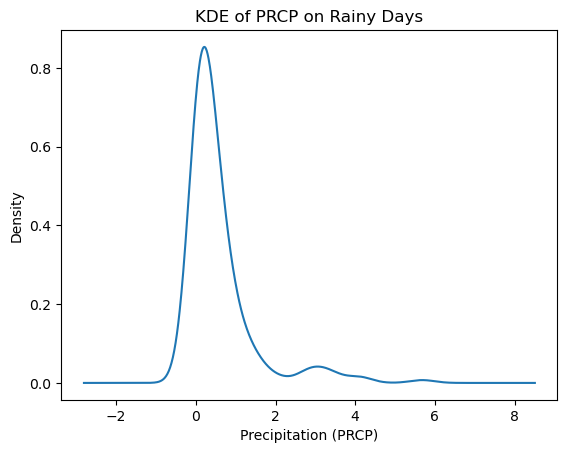

In [48]:
import matplotlib.pyplot as plt

weather.loc[weather["rain"] == 1, "PRCP"].plot(kind="kde", title="KDE of PRCP on Rainy Days")
plt.xlabel("Precipitation (PRCP)")
plt.show()


#### **Problem 3 Response**
All variables have missing data, excluding STATION, NAME, DATE, and PRCP. If it rained yesterady, there is a 65% chance of rain for today.If it was clear yesterday, there is a 27% chance of rain today. Regardless of starting clear or rainy, the chain settles to ~56.7% clear and 43.3% rain in the long run. Both starts hit essentially the same fixed (stationary) distribution π≈[0.5673,0.4327] in about 25 steps. To improve the model, I could add a third state (clear, light rain, heavy rain) to capture rain intensity instead of treating all rain as the same.

4. Taxicab trajectories: Using the pickled taxicab data, we want to complete the exercise from class.

- For the taxicab trajectory data, determine your state space and clean your sequences of cab rides.
- Compute the transition matrix for the taxicab data between neighborhoods in Manhattan. Plot it in a heat map. What are the most common routes?
- Explain why taxicabs are most likely order 1, and not 2 or more.
- Starting at Hell's Kitchen, create a sequence of forecasts of where the cab is likely to be in 2, 3, 5, and 10 trips
- Starting at any neighborhood, iterate your forecast until it is no longer changing very much. Where do cabs spend most of their time working in Manhattan?